In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [2]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    

Using notebook 3d backend.


In [3]:
import pandas as pd
import numpy as np
from mne_bids import BIDSPath
from tqdm import tqdm

task = [
        # 'LexicalNoDelay',
        'LexicalDelay',
        # 'PictureNaming',
        # 'SentenceRep',
        ]


ref = 'bipolar'
hga_paths = []
for t in task:
    hga_paths.extend(
        BIDSPath(
            root=f'../results/{t}({ref})',
            datatype='HGA',
            suffix='time',  # 注意这里改成 'time'
            check=False,
        ).match()
    )

# 2. 筛选 perception 和 passive 的数据
HGAs = []
for path in tqdm(hga_paths):
    df = pd.read_csv(path)
    # 只保留 perception 或 passive
    HGAs.append(df)

HGAs = pd.concat(HGAs)

# rename both phase : Resp and Response to Resp
HGAs.loc[HGAs.phase == 'Resp', 'phase'] = 'Response'
HGAs.loc[HGAs.phase == 'Audio', 'phase'] = 'Stimulus'

# phase all convert to lower
HGAs['phase'] = HGAs['phase'].str.lower()

# rename INS to 'Insula'
HGAs.loc[HGAs.roi == 'INS', 'roi'] = 'Insula'
# combine HG to STG
# HGAs.loc[HGAs.roi == 'HG', 'roi'] = 'STG'
HGAs.loc[HGAs.roi == 'PrG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'PoG', 'roi'] = 'SMC'
HGAs.loc[HGAs.roi == 'Subcentral', 'roi'] = 'SMC'


HGAs.loc[HGAs.label.isin([
    'ctx_lh_G_and_S_cingul-Mid-Post',
    'ctx_rh_G_and_S_cingul-Mid-Post',
    'ctx_lh_G_cingul-Post-dorsal'
    ]), 'roi'] = 'PCC'

dacc_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Ant',
    'ctx_rh_G_and_S_cingul-Mid-Ant'
]

HGAs.loc[HGAs.label.isin(dacc_labels), 'roi'] = 'dACC' # 这里的 dACC 就是最严格的 SN 枢纽
# rename CG to ACC
HGAs.loc[HGAs.roi=='CG', 'roi'] = 'ACC'
HGAs.head()

100%|██████████| 320/320 [00:06<00:00, 52.80it/s]


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0023_RPIF3-4,0.249398,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,41.901912,-28.228735,17.149502
1,-1.0,D0023_R2MF2-3,0.051112,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,11.195341,-7.769187,33.884895
2,-1.0,D0023_RPSF1-2,0.095070,False,CGs,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_S_pericallosal,6.423360,-15.496811,23.453189
3,-1.0,D0023_RPIF1-2,0.231350,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,35.187262,-26.860379,15.945394
4,-1.0,D0023_RPIF2-3,0.361105,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,38.280793,-27.303607,16.525972


In [4]:
# load a exlude pandas df
fpath = '../results/exlude_insula.csv'
exclude_df = pd.read_csv(fpath, index_col=0)
# exclude NaN columns and flatten into single list
exclude_chn = [electrode for item in exclude_df.Exclude.dropna() 
                for electrode in eval(item)]

HGAs = HGAs[~HGAs.channel.isin(exclude_chn)]
print(exclude_chn)

['D0040_L1IF2-3', 'D0040_L1IF3-4', 'D0079_LFAI1-2', 'D0079_LFAI2-3', 'D0079_LFMI1-2', 'D0079_LPI9-10', 'D0103_LAI7-8', 'D0103_LAI3-4', 'D0103_LAI5-6', 'D0103_LAI6-7']


In [5]:
# Insula region classification function for row-wise application
def classify_insula_row(row, y_threshold=0):
    """
    Classify a single insula electrode into AIC or PIC
    Designed for use with df.apply()
    
    Returns: 'AIC', 'PIC', or original roi if not insula
    """
    if row['roi'] != 'Insula':
        return row['roi']
    
    label = row['label']
    y_coord = row['y']
    
    # AIC classification conditions
    if ('G_insular_short' in label or 
        'S_circular_insula_ant' in label or
        ('S_circular_insula_sup' in label and y_coord > y_threshold) or
        ('S_circular_insula_inf' in label and y_coord > y_threshold)):
        return 'AIC'
    
    # PIC classification conditions  
    elif ('G_Ins_lg_and_S_cent_ins' in label or
          ('S_circular_insula_sup' in label and y_coord <= y_threshold) or
          ('S_circular_insula_inf' in label and y_coord <= y_threshold)):
        return 'PIC'
    
    # If no conditions match, return original
    return row['roi']

# Apply classification to entire DataFrame (function handles filtering internally)
HGAs['roi'] = HGAs.apply(classify_insula_row, axis=1, y_threshold=0)

# Statistics results
print(f"AIC electrode count: {len(HGAs[HGAs['roi'] == 'AIC'])}")
print(f"PIC electrode count: {len(HGAs[HGAs['roi'] == 'PIC'])}")

# Check unclassified electrodes
unclassified = HGAs[HGAs['roi'] == 'Insula']
if len(unclassified) > 0:
    print(f"Unclassified electrode count: {len(unclassified)}")
    print("Unclassified label types:", unclassified['label'].unique())
    
HGAs.head()

AIC electrode count: 74880
PIC electrode count: 67200


,time,channel,value,mask,roi,hemi,subject,description,task,phase,modality,label,x,y,z
0,-1.0,D0023_RPIF3-4,0.249398,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,41.901912,-28.228735,17.149502
1,-1.0,D0023_R2MF2-3,0.051112,False,Intersection,R,D0023,Decision,LexicalDelay,stimulus,sound,Intersection,11.195341,-7.769187,33.884895
2,-1.0,D0023_RPSF1-2,0.095070,False,CGs,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_S_pericallosal,6.423360,-15.496811,23.453189
3,-1.0,D0023_RPIF1-2,0.231350,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,35.187262,-26.860379,15.945394
4,-1.0,D0023_RPIF2-3,0.361105,False,Sylvian,R,D0023,Decision,LexicalDelay,stimulus,sound,ctx_rh_Lat_Fis-post,38.280793,-27.303607,16.525972


# Load data

In [6]:
bids_root = '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/'

In [32]:
# load label array
mne.set_log_level('WARNING')
phases = ['Stimulus','Delay', 'Go', 'Response']
conditions = ['Decision','Repeat']

epos = []

subset = HGAs[
    (HGAs.roi.isin(['PIC','AIC','STG','SMC','dACC',
                    'ITG','SMG','MTG','IFG','SFG',
                    'MFG','STS','AG','SPL','IPL',
                    'HG']))
    &(HGAs.task=='LexicalDelay')
]


for sub in tqdm(subset.subject.unique()):

    for phase in phases:
        
        picks = subset[subset.subject==sub].channel.unique().tolist()
        
        pt = BIDSPath(
            root=os.path.join(bids_root, 'derivatives', 'epoch(bipolar)'),
            subject=sub,
            datatype='epoch(band)(zscore)',
            processing=phase,
            suffix='highgamma',
            extension='.h5',
            check=False
        )

        for condition in conditions:
            epo_path = pt.update(description=condition).match()[0]
            dc_epo = mne.read_epochs(epo_path, verbose='error')
            onset = dc_epo.events[:, 0] / 2048
            dc_epo.metadata = pd.DataFrame({'onset': onset}, index=dc_epo.selection)
            dc_epo.pick(picks)
            df = dc_epo.to_data_frame(long_format=True, scalings={'seeg': 1}, verbose=False)
            meta = dc_epo.metadata.reset_index(names='epoch')  # epoch == selection
            df = df.merge(meta, on='epoch', how='left')

            df['phase'] = phase
            df['description'] = condition
            df['subject'] = sub
            df['remark'] = df['condition'].str.split('/').str[4:].str.join('/')
            df['condition'] = df['condition'].str.split('/').str[2:4].str.join('/')
            
            epos.append(df)

    break
epos = pd.concat(epos, ignore_index=True)
# only keep the correct trials
# epos = epos[epos.remark=='CORRECT']
epos.head()

  0%|          | 0/39 [00:14<?, ?it/s]


,condition,epoch,time,channel,ch_type,value,onset,phase,description,subject,remark
0,Word/latin,1,-1.0,D0023_RPIF8-9,seeg,1.199449,1232.113281,Stimulus,Decision,D0023,ERR_TASK/YN_REP
1,Word/latin,1,-1.0,D0023_RPIF9-10,seeg,-0.129328,1232.113281,Stimulus,Decision,D0023,ERR_TASK/YN_REP
2,Word/latin,1,-1.0,D0023_R2IF1-2,seeg,-0.705476,1232.113281,Stimulus,Decision,D0023,ERR_TASK/YN_REP
3,Word/latin,1,-1.0,D0023_R2MF10-11,seeg,-0.053457,1232.113281,Stimulus,Decision,D0023,ERR_TASK/YN_REP
4,Word/latin,1,-1.0,D0023_R2MF9-10,seeg,-0.130285,1232.113281,Stimulus,Decision,D0023,ERR_TASK/YN_REP


In [35]:
epoch_tbl

,subject,condition,description,phase,epoch,onset,remark,TRIAL
0,D0023,Word/latin,Decision,Stimulus,1,1232.113281,ERR_TASK/YN_REP,221.0
3520,D0023,Word/baron,Decision,Stimulus,6,1238.431641,ERR_TASK/YN_REP,173.0
7040,D0023,Word/tulip,Decision,Stimulus,11,1244.615723,ERR_TASK/YN_REP,323.0
10560,D0023,Nonword/revit,Decision,Stimulus,31,1269.855469,LATE_RESP,127.0
14080,D0023,Nonword/vanic,Decision,Stimulus,51,1294.840332,EARLY_RESP,161.0
...,...,...,...,...,...,...,...,...
4711360,D0023,Nonword/galem,Repeat,Response,1649,3795.606445,CORRECT,40.0
4714880,D0023,Nonword/laken,Repeat,Response,1654,3801.909180,CORRECT,76.0
4718400,D0023,Nonword/banic,Repeat,Response,1659,3808.507812,CORRECT,4.0
4721920,D0023,Word/sonic,Repeat,Response,1664,3815.082031,CORRECT,308.0


In [ ]:
# ----------------------------------------------------------------------
# 1) Build a trial-level table from epoch-level metadata (one row per epoch)
# ----------------------------------------------------------------------
epoch_tbl = (
    epos[['subject', 'epoch', 'condition', 'description', 'phase', 'onset', 'remark']]
    .drop_duplicates()
)

# ----------------------------------------------------------------------
# 2) Assign a unique trial number (TRIAL) to each real trial.
#    - Trials are defined by the onset of the Stimulus phase.
#    - Within each subject, we count Stimulus events in chronological order.
# ----------------------------------------------------------------------
epoch_tbl = epoch_tbl.sort_values(['subject', 'onset', 'epoch']).reset_index(drop=True)

epoch_tbl['trial'] = (
    epoch_tbl
    .groupby(['subject'], sort=False)['phase']
    .transform(lambda s: s.eq('Stimulus').cumsum())
)
# Rows before the first Stimulus (if any) will have trial=0; set them to NaN.
epoch_tbl.loc[epoch_tbl['trial'].eq(0), 'trial'] = np.nan

# ----------------------------------------------------------------------
# 3) Extract Go and Response onsets for each trial and compute RT.
#    - Pivot the long table so each trial has one row with go_onset and resp_onset.
#    - RT = resp_onset - go_onset.
# ----------------------------------------------------------------------
go_resp_onset = (
    epoch_tbl[epoch_tbl['phase'].isin(['Go', 'Response'])]
    .pivot_table(
        index=['subject', 'description', 'trial', 'condition'],
        columns='phase',
        values='onset',
        aggfunc='first'
    )
    .reset_index()
    .rename(columns={'Go': 'go_onset', 'Response': 'resp_onset'})
)

go_resp_onset['rt'] = go_resp_onset['resp_onset'] - go_resp_onset['go_onset']

# ----------------------------------------------------------------------
# 4) Merge RT back into the epoch-level table.
#    - Use subject, description, trial, and condition as the join key.
# ----------------------------------------------------------------------
epoch_tbl = epoch_tbl.merge(
    go_resp_onset[['subject', 'description', 'trial', 'condition', 'rt']],
    on=['subject', 'description', 'trial', 'condition'],
    how='left'
)

# ----------------------------------------------------------------------
# 5) Optional: Keep only correct trials for downstream analysis.
# ----------------------------------------------------------------------
epoch_tbl = epoch_tbl[epoch_tbl.remark.eq('CORRECT')]
epoch_tbl.head(n=40)

,subject,epoch,condition,description,phase,onset,remark,trial,rt
12,D0023,16,Word/sonar,Repeat,Stimulus,1250.897949,CORRECT,4.0,0.578613
13,D0023,17,Word/sonar,Repeat,Delay,1251.539551,CORRECT,4.0,0.578613
14,D0023,18,Word/sonar,Repeat,Go,1252.748047,CORRECT,4.0,0.578613
15,D0023,19,Word/sonar,Repeat,Response,1253.326660,CORRECT,4.0,0.578613
16,D0023,21,Nonword/maled,Repeat,Stimulus,1257.294922,CORRECT,5.0,0.767578
17,D0023,22,Nonword/maled,Repeat,Delay,1257.890625,CORRECT,5.0,0.767578
18,D0023,23,Nonword/maled,Repeat,Go,1258.988281,CORRECT,5.0,0.767578
19,D0023,24,Nonword/maled,Repeat,Response,1259.755859,CORRECT,5.0,0.767578
20,D0023,26,Word/libel,Repeat,Stimulus,1263.556152,CORRECT,6.0,0.627930
21,D0023,27,Word/libel,Repeat,Delay,1264.146973,CORRECT,6.0,0.627930


In [20]:
# 用 merge_asof 按 onset 时间匹配：每个 Go/Resp 找到它之前最近的 Delay
epoch_tbl = (
    epos[['subject', 'description', 'phase', 'epoch', 'onset', 'condition']]
    .drop_duplicates()
)

delay = epoch_tbl[epoch_tbl['phase'].eq('Delay')][['subject','description','condition','epoch','onset']].rename(columns={'epoch':'delay_epoch','onset':'delay_onset'})
go    = epoch_tbl[epoch_tbl['phase'].eq('Go')][['subject','description','epoch','onset']].rename(columns={'epoch':'go_epoch','onset':'go_onset'})
resp  = epoch_tbl[epoch_tbl['phase'].eq('Response')][['subject','description','epoch','onset']].rename(columns={'epoch':'resp_epoch','onset':'resp_onset'})

# 给每个 Delay 分配唯一 trial_idx（按 subject + description 分组）
delay = delay.sort_values(['delay_onset','subject','description'], kind='mergesort').reset_index(drop=True)
delay['trial_idx'] = delay.groupby(['subject','description']).cumcount()

# merge_asof 需要 left/right 在 on 上全局严格排序
go = go.dropna(subset=['go_onset']).sort_values(['go_onset','subject','description'], kind='mergesort').reset_index(drop=True)
resp = resp.dropna(subset=['resp_onset']).sort_values(['resp_onset','subject','description'], kind='mergesort').reset_index(drop=True)

# merge_asof: 每个 Go 找到它之前最近的 Delay
go_matched = pd.merge_asof(
    go,
    delay[['subject','description','delay_onset','trial_idx']],
    by=['subject','description'],
    left_on='go_onset',
    right_on='delay_onset',
    direction='backward'
)

resp_matched = pd.merge_asof(
    resp,
    delay[['subject','description','delay_onset','trial_idx']],
    by=['subject','description'],
    left_on='resp_onset',
    right_on='delay_onset',
    direction='backward'
)

# 合并到 delay 表（保留 condition）
trials = (
    delay
    .merge(go_matched[['subject','description','trial_idx','go_onset','go_epoch']], on=['subject','description','trial_idx'], how='left')
    .merge(resp_matched[['subject','description','trial_idx','resp_onset','resp_epoch']], on=['subject','description','trial_idx'], how='left')
)

trials['rt'] = trials['resp_onset'] - trials['go_onset']
trials.head(10)

,subject,description,condition,delay_epoch,delay_onset,trial_idx,go_onset,go_epoch,resp_onset,resp_epoch,rt
0,D0079,Decision,Word/petal,2,12.631348,0,13.876465,3,14.775879,4,0.899414
1,D0079,Decision,Word/cabin,7,19.450684,1,20.774414,8,21.610840,9,0.836426
2,D0079,Decision,Word/tenet,12,26.445312,2,27.509277,13,28.125488,14,0.616211
3,D0079,Repeat,Word/petal,17,33.200195,0,34.412109,18,35.350098,19,0.937988
4,D0079,Repeat,Nonword/delin,22,40.022949,1,41.127441,23,42.136719,24,1.009277
5,D0079,Repeat,Word/rival,27,46.877930,2,48.028320,28,48.828125,29,0.799805
6,D0079,Decision,Nonword/lomic,32,53.933594,3,55.145020,33,56.033691,34,0.888672
7,D0079,Repeat,Word/manic,37,60.837402,3,62.028809,38,63.047363,39,1.018555
8,D0079,Repeat,Nonword/herib,42,67.639648,4,68.793457,43,69.917969,44,1.124512
9,D0079,Repeat,Nonword/labin,47,74.533203,5,75.776855,48,76.883301,49,1.106445


In [22]:
# 把 RT merge 回包含 Delay/Go/Response 的长表
# 构建 phase+epoch -> idx/rt/condition 的映射
phase_map = pd.concat([
    trials[['subject','description','trial_idx','condition','rt','delay_epoch']]
        .rename(columns={'trial_idx':'idx','delay_epoch':'epoch'})
        .assign(phase='Delay'),
    trials[['subject','description','trial_idx','condition','rt','go_epoch']]
        .rename(columns={'trial_idx':'idx','go_epoch':'epoch'})
        .assign(phase='Go'),
    trials[['subject','description','trial_idx','condition','rt','resp_epoch']]
        .rename(columns={'trial_idx':'idx','resp_epoch':'epoch'})
        .assign(phase='Response'),
], ignore_index=True)


epos = (
    epos
    .merge(
        phase_map,
        on=['subject','description','phase','epoch'],
        how='left',
        suffixes=('', '_trial')
    )
    .drop(columns=['condition_trial'])
)

epos = epos[(
    (epos.rt<2)
    & (epos.rt>0)
)]

epos.head()

,condition,epoch,time,channel,ch_type,value,onset,phase,description,subject,remark,idx,rt
0,Word/tonic,82,-1.0,D0023_RPIF8-9,seeg,0.645598,1333.505371,Delay,Decision,D0023,CORRECT,0,0.361328
1,Word/tonic,82,-1.0,D0023_RPIF9-10,seeg,-0.192236,1333.505371,Delay,Decision,D0023,CORRECT,0,0.361328
2,Word/tonic,82,-1.0,D0023_R2IF1-2,seeg,-0.257336,1333.505371,Delay,Decision,D0023,CORRECT,0,0.361328
3,Word/tonic,82,-1.0,D0023_R2MF10-11,seeg,-0.165871,1333.505371,Delay,Decision,D0023,CORRECT,0,0.361328
4,Word/tonic,82,-1.0,D0023_R2MF9-10,seeg,-0.363279,1333.505371,Delay,Decision,D0023,CORRECT,0,0.361328


In [23]:
# 提取 Delay (time>0) 和 Go (time<0) 的神经特征
# 每个 trial 计算 mean 和 slope

from scipy.ndimage import gaussian_filter1d

def compute_slope(x, t):
    """线性回归斜率：y = a*t + b，返回 a"""
    if len(t) < 2:
        return np.nan
    return np.polyfit(t, x, 1)[0]

def smooth_gaussian(x, t, sigma_s=0.05):
    """对不等长序列做高斯平滑：sigma_s 以秒为单位"""
    if len(t) < 3:
        return x
    # 假设 t 基本等间隔，用中位数 dt 换算到 sample
    dt = np.median(np.diff(t))
    if not np.isfinite(dt) or dt <= 0:
        return x
    sigma_samples = sigma_s / dt
    if not np.isfinite(sigma_samples) or sigma_samples <= 0:
        return x
    return gaussian_filter1d(x, sigma=sigma_samples, mode='nearest')

# 平滑窗口：推荐 sigma=50ms（你可以在 20-100ms 之间扫一下）
SIGMA_S = 0.05

# 筛选感兴趣的时间窗
delay_data = epos[(epos['phase'] == 'Delay') & (epos['time'] > 0)]
go_data = epos[(epos['phase'] == 'Go') & (epos['time'] < 0)]

# 合并 Delay + Go 作为 "准备期"
prep_data = pd.concat([delay_data, go_data], ignore_index=True)

# 按 trial 聚合：mean 和 slope（先按 time 排序并平滑）
features = (
    prep_data
    .sort_values(['subject','description','idx','channel','time'])
    .groupby(['subject', 'description', 'idx', 'rt', 'channel'])
    .apply(
        lambda g: pd.Series(
            (lambda t, x: {
                'mean_hga': smooth_gaussian(x, t, sigma_s=SIGMA_S).mean(),
                'slope_hga': compute_slope(smooth_gaussian(x, t, sigma_s=SIGMA_S), t),
            })(g['time'].values, g['value'].values)
        ),
        include_groups=False,
    )
    .reset_index()
)

features.head()

,subject,description,idx,rt,channel,mean_hga,slope_hga
0,D0023,Decision,0,0.361328,D0023_R1MF1-2,0.329784,-0.091404
1,D0023,Decision,0,0.361328,D0023_R1MF14-15,-0.012152,0.057121
2,D0023,Decision,0,0.361328,D0023_R2IF1-2,-0.184047,0.098865
3,D0023,Decision,0,0.361328,D0023_R2IF2-3,-0.126505,0.267281
4,D0023,Decision,0,0.361328,D0023_R2MF1-2,0.202421,0.185552


In [24]:
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

channel_trial_features = features.copy()
channel_models = []

for channel in channel_trial_features['channel'].unique():
    chan_data = channel_trial_features[channel_trial_features['channel'] == channel].copy()

    if len(chan_data) < 50:
        continue

    # 标准化特征（z-score，按该 channel 自身分布）
    mean_std = chan_data['mean_hga'].std()
    slope_std = chan_data['slope_hga'].std()
    if (not np.isfinite(mean_std)) or mean_std == 0 or (not np.isfinite(slope_std)) or slope_std == 0:
        continue

    chan_data['mean_hga_z'] = (chan_data['mean_hga'] - chan_data['mean_hga'].mean()) / mean_std
    chan_data['slope_hga_z'] = (chan_data['slope_hga'] - chan_data['slope_hga'].mean()) / slope_std

    X = sm.add_constant(chan_data[['mean_hga_z', 'slope_hga_z']])
    y = chan_data['rt']

    # OLS（可选：cov_type='HC3' 做稳健标准误；这里先用默认）
    res = sm.OLS(y, X).fit()

    channel_models.append({
        'channel': channel,
        'subject': chan_data['subject'].iloc[0],
        'n_trials': len(chan_data),
        'mean_coef': res.params.get('mean_hga_z', np.nan),
        'slope_coef': res.params.get('slope_hga_z', np.nan),
        'mean_p': res.pvalues.get('mean_hga_z', np.nan),
        'slope_p': res.pvalues.get('slope_hga_z', np.nan),
        'r2': res.rsquared,
    })

channel_results = pd.DataFrame(channel_models)

# FDR 校正
_, channel_results['mean_p_fdr'], _, _ = multipletests(channel_results['mean_p'], method='fdr_bh')
_, channel_results['slope_p_fdr'], _, _ = multipletests(channel_results['slope_p'], method='fdr_bh')

channel_results = channel_results.sort_values('mean_p_fdr')

channel_results.head(10)

,channel,subject,n_trials,mean_coef,slope_coef,mean_p,slope_p,r2,mean_p_fdr,slope_p_fdr
308,D0079_LPAM14-15,D0079,284,-0.164380,-0.134502,7.858804e-16,1.900778e-11,0.293963,4.228036e-13,2.045237e-09
425,D0092_RTAM14-15,D0092,229,0.152458,0.068402,4.635521e-13,6.736600e-04,0.207425,1.246955e-10,6.711650e-03
56,D0029_LPSF6-7,D0029,321,-0.090522,-0.034126,1.028489e-12,5.423134e-03,0.156331,1.844423e-10,3.446500e-02
367,D0084_RPI13-14,D0084,271,-0.139040,-0.063772,7.878909e-11,2.090855e-03,0.185332,1.059713e-08,1.757625e-02
5,D0023_R2MF10-11,D0023,292,-0.113613,-0.112190,2.487052e-10,4.007724e-10,0.253534,2.230056e-08,3.080222e-08
503,D0102_RFPI5-6,D0102,309,-0.071757,-0.057902,2.104047e-10,2.162633e-07,0.239678,2.230056e-08,8.310688e-06
359,D0084_RFMM10-11,D0084,271,-0.128704,-0.024202,4.774669e-09,2.560332e-01,0.121365,3.669675e-07,4.653577e-01
57,D0029_LPSF7-8,D0029,321,-0.074029,-0.022400,1.328219e-08,7.845239e-02,0.098373,8.843209e-07,2.221441e-01
6,D0023_R2MF9-10,D0023,292,-0.101402,-0.123840,1.479347e-08,8.571340e-12,0.235263,8.843209e-07,1.605018e-09
502,D0102_RFPI4-5,D0102,309,-0.064295,-0.049523,1.797509e-08,1.175824e-05,0.164877,9.670600e-07,2.433051e-04


In [12]:
# 单电极预测：10-fold Cross Validation（每个 channel 内部）
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error

cv_rows = []

for channel in features['channel'].unique():
    dfc = features[features['channel'] == channel].copy()
    if len(dfc) < 50:
        continue

    X_raw = dfc[['mean_hga', 'slope_hga']].values
    y = dfc['rt'].values

    # 10-fold（如果 trial 太少则降到最多 len-1 folds）
    n_splits = min(15, len(dfc))
    if n_splits < 2:
        continue

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    y_pred_all = np.empty_like(y, dtype=float)

    for train_idx, test_idx in kf.split(X_raw):
        X_train_raw = X_raw[train_idx]
        X_test_raw = X_raw[test_idx]
        y_train = y[train_idx]

        # 在训练集上做标准化（避免数据泄漏）
        mu = X_train_raw.mean(axis=0)
        sd = X_train_raw.std(axis=0, ddof=0)
        sd[sd == 0] = 1.0

        X_train = (X_train_raw - mu) / sd
        X_test = (X_test_raw - mu) / sd

        X_train = sm.add_constant(X_train)
        X_test = sm.add_constant(X_test)

        res = sm.OLS(y_train, X_train).fit()
        y_pred_all[test_idx] = res.predict(X_test)

    cv_r2 = r2_score(y, y_pred_all)
    cv_rmse = float(np.sqrt(mean_squared_error(y, y_pred_all)))

    cv_rows.append({'channel': channel, 'cv_r2': cv_r2, 'cv_rmse': cv_rmse, 'cv_n': len(dfc)})

cv_results = pd.DataFrame(cv_rows)

# merge 回 channel_results（如果上一个 cell 已经生成 channel_results）
channel_results = channel_results.merge(cv_results, on='channel', how='left')
channel_results.sort_values('cv_r2', ascending=False).head(10)

,channel,subject,n_trials,mean_coef,slope_coef,mean_p,slope_p,r2,mean_p_fdr,slope_p_fdr,cv_r2,cv_rmse,cv_n
0,D0079_LPAM14-15,D0079,328,-0.165412,-0.137331,5.913934e-17,1.680493e-12,0.273710,3.181697e-14,2.666787e-10,0.262687,0.338031,328
5,D0023_R2MF10-11,D0023,320,-0.115856,-0.122143,6.334218e-11,6.617252e-12,0.260283,5.679682e-09,5.933469e-10,0.227999,0.308119,320
4,D0102_RFPI5-6,D0102,320,-0.074661,-0.055709,6.180123e-11,7.364480e-07,0.232615,5.679682e-09,2.330641e-05,0.218623,0.190781,320
8,D0023_R2MF9-10,D0023,320,-0.104938,-0.126828,3.831587e-09,1.982741e-12,0.232513,2.290437e-07,2.666787e-10,0.206317,0.312416,320
18,D0053_LPIF12-14,D0053,322,-0.068914,-0.096963,5.129393e-07,4.006135e-12,0.212248,1.452428e-05,4.310601e-10,0.190983,0.241880,322
453,D0027_LMSF3-4,D0027,288,0.008685,0.189846,6.926761e-01,3.881322e-16,0.211937,8.208365e-01,2.088151e-13,0.190469,0.367371,288
2,D0084_RPI13-14,D0084,319,-0.144199,-0.078551,8.401248e-12,1.341260e-04,0.184463,1.506624e-09,1.628152e-03,0.168379,0.362328,319
1,D0029_LPSF6-7,D0029,331,-0.096441,-0.035643,2.047362e-14,3.304261e-03,0.171899,5.507405e-12,2.141798e-02,0.149987,0.218962,331
291,D0065_RPIT11-12,D0065,287,-0.018701,-0.125900,2.561228e-01,2.928645e-13,0.175204,4.729397e-01,7.878054e-11,0.144399,0.281540,287
3,D0092_RTAM14-15,D0092,242,0.140185,0.067459,3.249810e-11,9.410877e-04,0.168595,4.370994e-09,8.300085e-03,0.141898,0.273530,242


In [25]:
subset = HGAs[['channel', 'roi','hemi','description','task','phase','label','x','y','z']].drop_duplicates()
channel_results = channel_results.merge(subset, on='channel', how='left')
channel_results.head()

,channel,subject,n_trials,mean_coef,slope_coef,mean_p,slope_p,r2,mean_p_fdr,slope_p_fdr,roi,hemi,description,task,phase,label,x,y,z
0,D0079_LPAM14-15,D0079,284,-0.16438,-0.134502,7.858804e-16,1.900778e-11,0.293963,4.228036e-13,2.045237e-09,SMC,L,Decision,LexicalDelay,delay,ctx_lh_S_postcentral,-49.319665,-21.3642,36.147167
1,D0079_LPAM14-15,D0079,284,-0.16438,-0.134502,7.858804e-16,1.900778e-11,0.293963,4.228036e-13,2.045237e-09,SMC,L,Repeat,LexicalDelay,delay,ctx_lh_S_postcentral,-49.319665,-21.3642,36.147167
2,D0079_LPAM14-15,D0079,284,-0.16438,-0.134502,7.858804e-16,1.900778e-11,0.293963,4.228036e-13,2.045237e-09,SMC,L,Decision,LexicalDelay,go,ctx_lh_S_postcentral,-49.319665,-21.3642,36.147167
3,D0079_LPAM14-15,D0079,284,-0.16438,-0.134502,7.858804e-16,1.900778e-11,0.293963,4.228036e-13,2.045237e-09,SMC,L,Repeat,LexicalDelay,go,ctx_lh_S_postcentral,-49.319665,-21.3642,36.147167
4,D0079_LPAM14-15,D0079,284,-0.16438,-0.134502,7.858804e-16,1.900778e-11,0.293963,4.228036e-13,2.045237e-09,SMC,L,Decision,LexicalDelay,response,ctx_lh_S_postcentral,-49.319665,-21.3642,36.147167


VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-19 16:45:06.099 (9008.144s) [    7EFF729ED440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x109df600): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card0: Permission denied

2026-01-19 16:45:06.160 (9008.205s) [    7EFF729ED440] vtkEGLRenderWindow.cxx:353   WARN| vtkEGLRenderWindow (0x109df600): EGL device index: 0 could not be initialized. Trying other devices...
VMware: No 3D enabled (0, Success).
libEGL warning: egl: failed to create dri2 screen
VMware: No 3D enabled (0, Success).
libEGL warning: 

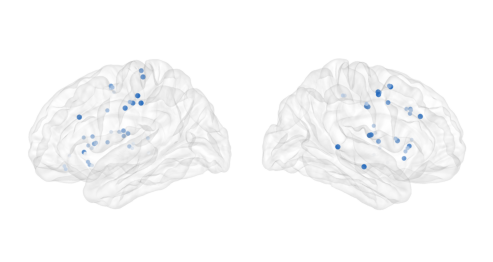

In [30]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from mne.viz import Brain
from scipy.spatial import cKDTree

df = channel_results[channel_results.roi.isin(['AIC','PIC','SMC','IFG','ACC','dACC','STG'])].dropna(subset=['x','y','z', 'r2', 'mean_p_fdr']).copy()
df = df[df['mean_p_fdr'] < 0.05]

coords = df[['x','y','z']].values
vals = df['r2'].values

vmin = np.nanpercentile(vals, 0)
vmax = np.nanpercentile(vals, 80)
if not np.isfinite(vmin):
    vmin = np.nanmin(vals)
if not np.isfinite(vmax):
    vmax = np.nanmax(vals)
if vmin == vmax:
    vmax = vmin + 1e-6

cmap = blues
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

sizes = 20 + 10 * np.clip((vals - vmin) / (vmax - vmin), 0, 1)

lh_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/lh.pial")
rh_coords, _ = mne.read_surface(f"{recon_dir}/fsaverage/surf/rh.pial")
lh_tree = cKDTree(lh_coords)
rh_tree = cKDTree(rh_coords)

lh = Brain('fsaverage', subjects_dir=recon_dir, hemi='lh', surf='pial', background='white', show=False, cortex=(0.9,0.9,0.9), alpha=0.15, size=(600*cm, 600*cm))
rh = Brain('fsaverage', subjects_dir=recon_dir, hemi='rh', surf='pial', background='white', show=False, cortex=(0.9,0.9,0.9), alpha=0.15, size=(600*cm, 600*cm))

mask_lh = coords[:, 0] < 0
mask_rh = coords[:, 0] > 0

if mask_lh.any():
    _, idx = lh_tree.query(coords[mask_lh])
    proj = lh_coords[idx]
    for pt, v, s in zip(proj, vals[mask_lh], sizes[mask_lh]):
        lh._renderer.plotter.add_mesh(pv.PolyData(pt.reshape(1,3)), render_points_as_spheres=True, point_size=float(s), color=cmap(norm(v))[:3], lighting=False, opacity=0.95)

if mask_rh.any():
    _, idx = rh_tree.query(coords[mask_rh])
    proj = rh_coords[idx]
    for pt, v, s in zip(proj, vals[mask_rh], sizes[mask_rh]):
        rh._renderer.plotter.add_mesh(pv.PolyData(pt.reshape(1,3)), render_points_as_spheres=True, point_size=float(s), color=cmap(norm(v))[:3], lighting=False, opacity=0.95)

for b in (lh, rh):
    b.show_view(view='lateral', distance=400)
    b._renderer.plotter.window_size = [1400, 1400]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16*cm, 8*cm), gridspec_kw={'width_ratios': [1, 1]})
plt.subplots_adjust(wspace=-0.1)
ax1.imshow(lh.screenshot(mode='rgb'))
ax1.axis('off')
ax2.imshow(rh.screenshot(mode='rgb'))
ax2.axis('off')

lh.close()
rh.close()

fig.savefig(f'../img/fig4/fig4_RT_spatial.svg', dpi=300, bbox_inches='tight')